In [12]:
import requests
import os
import json
import time
import pandas as pd
from pathlib import Path
from PIL import Image
from io import BytesIO
from tqdm import tqdm

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [13]:
import requests
import os
import json
import time
import pandas as pd
from pathlib import Path
from PIL import Image
from io import BytesIO
from tqdm import tqdm

# ─── IDs verificados directamente desde iNaturalist ───
SPECIES = {
    "aquila_audax": {
        "scientific_name": "Aquila audax",
        "common_name":     "Wedge-tailed Eagle",
        "taxon_id":        5080
    },
    "falco_peregrinus": {
        "scientific_name": "Falco peregrinus",
        "common_name":     "Peregrine Falcon",
        "taxon_id":        4647
    },
    "circus_assimilis": {
        "scientific_name": "Circus assimilis",
        "common_name":     "Spotted Harrier",
        "taxon_id":        5175
    },
    "tachyspiza_fasciata": {
        # Reclasificada a Tachyspiza fasciata en iNaturalist
        "scientific_name": "Tachyspiza fasciata",
        "common_name":     "Brown Goshawk",
        "taxon_id":        1583256
    },
    "falco_cenchroides": {
        "scientific_name": "Falco cenchroides",
        "common_name":     "Nankeen Kestrel",
        "taxon_id":        4681
    },
    "elanus_axillaris": {
        "scientific_name": "Elanus axillaris",
        "common_name":     "Black-shouldered Kite",
        "taxon_id":        5276
    },
    "lophoictinia_isura": {
        "scientific_name": "Lophoictinia isura",
        "common_name":     "Square-tailed Kite",
        "taxon_id":        5286
    },
    "hieraaetus_morphnoides": {
        "scientific_name": "Hieraaetus morphnoides",
        "common_name":     "Little Eagle",
        "taxon_id":        5150
    }
}

# ─── Carpetas del proyecto ─────────────────────────────
PROJECT_ROOT = Path("C:/Projects/raptor_australia")
RAW_DIR      = PROJECT_ROOT / "dataset" / "raw"

for species_key in SPECIES:
    (RAW_DIR / species_key).mkdir(parents=True, exist_ok=True)

print("✅ Diccionario SPECIES actualizado con IDs correctos\n")
print(f"{'Especie':<30} {'Taxon ID':>10}")
print("-" * 42)
for key, data in SPECIES.items():
    print(f"{data['common_name']:<30} {data['taxon_id']:>10}")

✅ Diccionario SPECIES actualizado con IDs correctos

Especie                          Taxon ID
------------------------------------------
Wedge-tailed Eagle                   5080
Peregrine Falcon                     4647
Spotted Harrier                      5175
Brown Goshawk                     1583256
Nankeen Kestrel                      4681
Black-shouldered Kite                5276
Square-tailed Kite                   5286
Little Eagle                         5150


In [14]:
def get_observations_inaturalist(taxon_id, species_key,
                                  max_results=300):
    """
    Descarga observaciones verificadas de iNaturalist
    para una especie en Australia.
    """
    base_url = "https://api.inaturalist.org/v1/observations"
    all_observations = []
    page = 1

    print(f"\n🔍 {SPECIES[species_key]['common_name']}"
          f" (taxon_id: {taxon_id})")

    while len(all_observations) < max_results:

        params = {
            "taxon_id":     taxon_id,
            "quality_grade":"research",
            "photos":       "true",
            "place_id":     6744,        # Australia
            "per_page":     100,
            "order":        "desc",
            "order_by":     "created_at",
            "page":         page
        }

        try:
            r = requests.get(
                base_url, params=params,
                headers={"User-Agent": "RaptorAustraliaResearch/1.0"},
                timeout=30
            )

            if r.status_code != 200:
                print(f"   ⚠️  HTTP {r.status_code} — {r.text[:150]}")
                break

            data    = r.json()
            results = data.get("results", [])

            if not results:
                break

            for obs in results:
                if len(all_observations) >= max_results:
                    break

                photos = obs.get("photos", [])
                if not photos:
                    continue

                photo = photos[0]

                # Tamaño medium (640px) — buena calidad, no muy pesado
                url = (photo.get("url") or "").replace("square", "medium")
                if not url:
                    continue

                loc    = obs.get("location") or "0,0"
                coords = loc.split(",") if "," in loc else ["0", "0"]

                all_observations.append({
                    "obs_id":          obs.get("id"),
                    "species_key":     species_key,
                    "scientific_name": SPECIES[species_key]["scientific_name"],
                    "common_name":     SPECIES[species_key]["common_name"],
                    "photo_id":        photo.get("id"),
                    "url":             url,
                    "license":         photo.get("license_code", "unknown"),
                    "date_observed":   obs.get("observed_on"),
                    "latitude":        coords[0].strip(),
                    "longitude":       coords[1].strip(),
                    "quality_grade":   obs.get("quality_grade"),
                    "num_agreements":  obs.get(
                                       "num_identification_agreements", 0),
                    "source":          "iNaturalist"
                })

            print(f"   Página {page}: {len(results):>3} resultados | "
                  f"Acumulado: {len(all_observations)}")

            page += 1
            time.sleep(1)

            if len(results) < 100:
                break

        except requests.exceptions.RequestException as e:
            print(f"   ⚠️  Error de conexión: {e}")
            time.sleep(5)
            break

    print(f"   ✅ Total: {len(all_observations)} observaciones")
    return all_observations

print("✅ Función get_observations definida")

✅ Función get_observations definida


In [15]:
def download_image(url, save_path, min_size_px=224):
    """
    Descarga y valida una imagen.
    min_size_px=224 porque EfficientNetB4 necesita al menos 224px.
    """
    try:
        r = requests.get(
            url,
            headers={"User-Agent": "RaptorAustraliaResearch/1.0"},
            timeout=20
        )
        r.raise_for_status()

        img = Image.open(BytesIO(r.content))
        w, h = img.size

        if w < min_size_px or h < min_size_px:
            return False, f"Muy pequeña: {w}x{h}px"

        if img.mode != "RGB":
            img = img.convert("RGB")

        img.save(save_path, "JPEG", quality=90)
        return True, f"{w}x{h}px"

    except Exception as e:
        return False, str(e)

print("✅ Función download_image definida")

✅ Función download_image definida


In [16]:
def download_species(species_key, max_images=300):
    """
    Orquesta la descarga completa de una especie.
    """
    taxon_id = SPECIES[species_key]["taxon_id"]
    save_dir = RAW_DIR / species_key
    log_path = (PROJECT_ROOT / "dataset" / "metadata"
                / f"{species_key}_log.csv")

    print(f"\n{'='*55}")
    print(f"  {SPECIES[species_key]['common_name'].upper()}")
    print(f"{'='*55}")

    # Paso 1 — Obtener lista de observaciones
    observations = get_observations_inaturalist(
        taxon_id=taxon_id,
        species_key=species_key,
        max_results=max_images
    )

    if not observations:
        print("❌ Sin observaciones disponibles")
        return []

    # Paso 2 — Descargar imágenes
    log_data   = []
    downloaded = 0
    failed     = 0
    skipped    = 0

    print(f"\n📥 Descargando {len(observations)} imágenes...")

    for obs in tqdm(observations,
                    desc=f"  {SPECIES[species_key]['common_name'][:25]}"):

        filename  = (f"{species_key}_"
                     f"{obs['obs_id']}_{obs['photo_id']}.jpg")
        save_path = save_dir / filename

        if save_path.exists():
            skipped += 1
            obs.update({"local_path": str(save_path),
                        "status": "already_exists"})
        else:
            success, info = download_image(obs["url"], save_path)
            if success:
                downloaded += 1
                obs.update({"local_path":  str(save_path),
                            "status":      "downloaded",
                            "resolution":  info})
            else:
                failed += 1
                obs.update({"local_path": None,
                            "status":     f"failed: {info}"})

        log_data.append(obs)
        time.sleep(0.2)

    # Paso 3 — Guardar log
    pd.DataFrame(log_data).to_csv(log_path, index=False)

    print(f"\n  ✅ Descargadas:  {downloaded}")
    print(f"  ⏭️  Ya existían: {skipped}")
    print(f"  ❌ Fallidas:    {failed}")
    print(f"  📁 Log: {log_path.name}")

    return log_data

print("✅ Función download_species definida")

✅ Función download_species definida


In [17]:
# Prueba solo con la primera especie
test = download_species(
    species_key="aquila_audax",
    max_images=50
)

print(f"\n✅ Prueba completada — {len(test)} registros procesados")
exitosas = sum(1 for t in test if t.get("status") == "downloaded")
print(f"   Imágenes descargadas: {exitosas}")


  WEDGE-TAILED EAGLE

🔍 Wedge-tailed Eagle (taxon_id: 5080)
   Página 1: 100 resultados | Acumulado: 50
   ✅ Total: 50 observaciones

📥 Descargando 50 imágenes...


  Wedge-tailed Eagle: 100%|██████████| 50/50 [00:10<00:00,  4.75it/s]


  ✅ Descargadas:  1
  ⏭️  Ya existían: 49
  ❌ Fallidas:    0
  📁 Log: aquila_audax_log.csv

✅ Prueba completada — 50 registros procesados
   Imágenes descargadas: 1


Imágenes en disco: 314


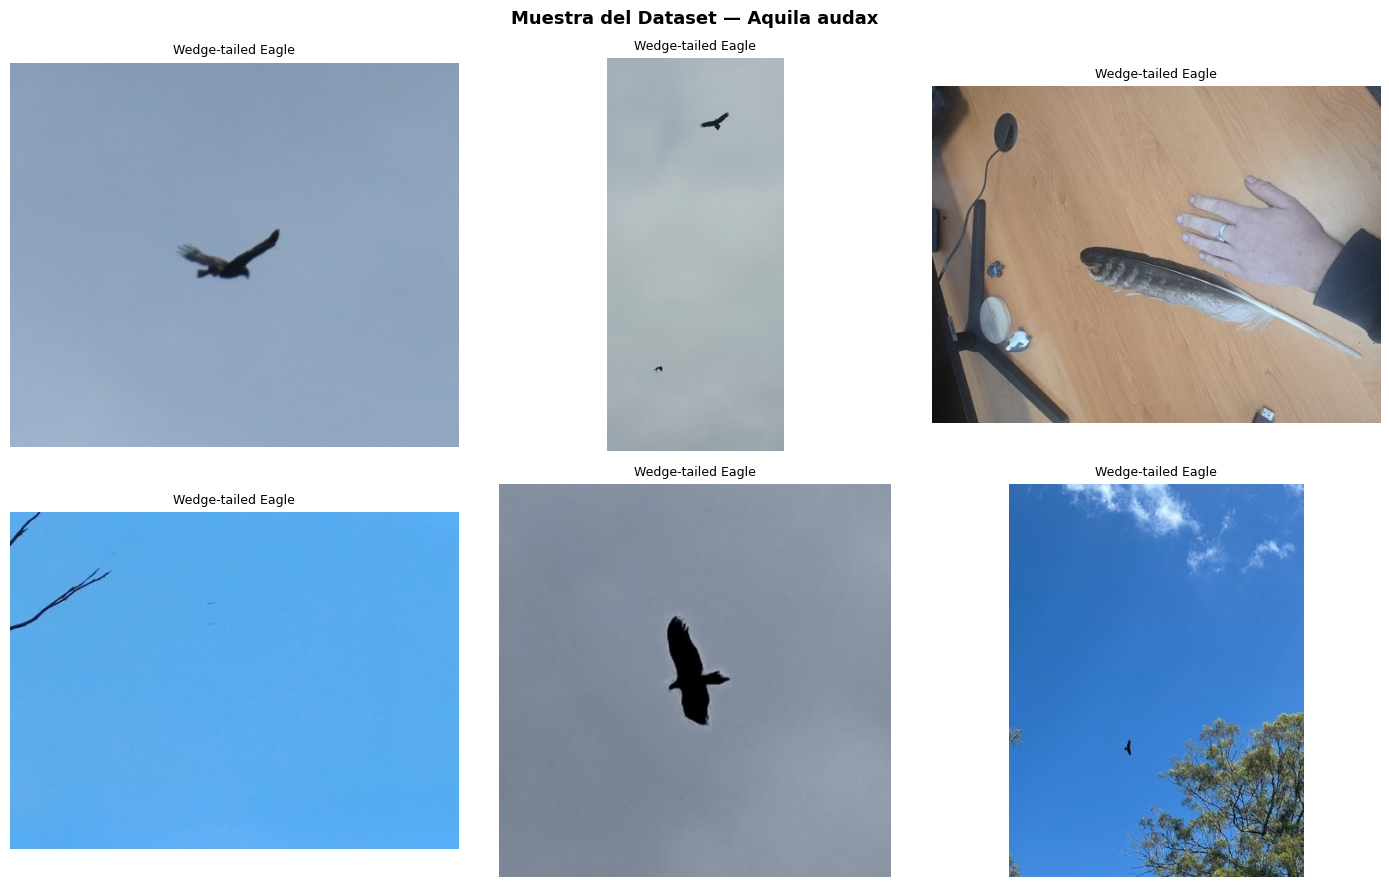

✅ Imagen guardada en results/


In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

species_dir = RAW_DIR / "aquila_audax"
images      = list(species_dir.glob("*.jpg"))

print(f"Imágenes en disco: {len(images)}")

# Mostrar cuadrícula 2x3
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, img_path in zip(axes.flatten(), images[:6]):
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.set_title("Wedge-tailed Eagle", fontsize=9)
    ax.axis("off")

# Apagar ejes sobrantes si hay menos de 6 imágenes
for ax in axes.flatten()[len(images[:6]):]:
    ax.axis("off")

plt.suptitle("Muestra del Dataset — Aquila audax",
             fontsize=13, fontweight="bold")
plt.tight_layout()

out = PROJECT_ROOT / "results" / "muestra_aquila_audax.png"
plt.savefig(str(out), dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Imagen guardada en results/")

In [19]:
# Descargar las 8 especies completas
# 300 imágenes por especie = ~2,400 imágenes totales

resultados_totales = {}

for species_key in SPECIES:
    resultado = download_species(
        species_key=species_key,
        max_images=300
    )
    resultados_totales[species_key] = resultado
    
    # Pausa entre especies para respetar la API
    print(f"\n⏳ Pausa de 5 segundos antes de la siguiente especie...")
    time.sleep(5)

print("\n" + "="*55)
print("DESCARGA COMPLETA — RESUMEN FINAL")
print("="*55)

total_imagenes = 0
for species_key, data in resultados_totales.items():
    descargadas = sum(1 for d in data if d.get("status") == "downloaded")
    existentes = sum(1 for d in data if d.get("status") == "already_exists")
    total = descargadas + existentes
    total_imagenes += total
    print(f"{SPECIES[species_key]['common_name']:30} → {total:4} imágenes")

print(f"\n{'TOTAL':30} → {total_imagenes:4} imágenes")
print("="*55)


  WEDGE-TAILED EAGLE

🔍 Wedge-tailed Eagle (taxon_id: 5080)
   Página 1: 100 resultados | Acumulado: 100
   Página 2: 100 resultados | Acumulado: 200
   Página 3: 100 resultados | Acumulado: 300
   ✅ Total: 300 observaciones

📥 Descargando 300 imágenes...


  Wedge-tailed Eagle: 100%|██████████| 300/300 [01:01<00:00,  4.88it/s]



  ✅ Descargadas:  0
  ⏭️  Ya existían: 299
  ❌ Fallidas:    1
  📁 Log: aquila_audax_log.csv

⏳ Pausa de 5 segundos antes de la siguiente especie...

  PEREGRINE FALCON

🔍 Peregrine Falcon (taxon_id: 4647)
   Página 1: 100 resultados | Acumulado: 100
   Página 2: 100 resultados | Acumulado: 200
   Página 3: 100 resultados | Acumulado: 300
   ✅ Total: 300 observaciones

📥 Descargando 300 imágenes...


  Peregrine Falcon: 100%|██████████| 300/300 [01:01<00:00,  4.90it/s]



  ✅ Descargadas:  0
  ⏭️  Ya existían: 299
  ❌ Fallidas:    1
  📁 Log: falco_peregrinus_log.csv

⏳ Pausa de 5 segundos antes de la siguiente especie...

  SPOTTED HARRIER

🔍 Spotted Harrier (taxon_id: 5175)
   Página 1: 100 resultados | Acumulado: 100
   Página 2: 100 resultados | Acumulado: 200
   Página 3: 100 resultados | Acumulado: 300
   ✅ Total: 300 observaciones

📥 Descargando 300 imágenes...


...


  ✅ Descargadas:  0
  ⏭️  Ya existían: 299
  ❌ Fallidas:    1
  📁 Log: elanus_axillaris_log.csv

⏳ Pausa de 5 segundos antes de la siguiente especie...

  SQUARE-TAILED KITE

🔍 Square-tailed Kite (taxon_id: 5286)
   Página 1: 100 resultados | Acumulado: 100
   Página 2: 100 resultados | Acumulado: 200
   Página 3: 100 resultados | Acumulado: 300
   ✅ Total: 300 observaciones

📥 Descargando 300 imágenes...


  Square-tailed Kite: 100%|██████████| 300/300 [01:01<00:00,  4.87it/s]



  ✅ Descargadas:  0
  ⏭️  Ya existían: 297
  ❌ Fallidas:    3
  📁 Log: lophoictinia_isura_log.csv

⏳ Pausa de 5 segundos antes de la siguiente especie...

  LITTLE EAGLE

🔍 Little Eagle (taxon_id: 5150)
   Página 1: 100 resultados | Acumulado: 100
   Página 2: 100 resultados | Acumulado: 200
   Página 3: 100 resultados | Acumulado: 300
   ✅ Total: 300 observaciones

📥 Descargando 300 imágenes...


  Little Eagle: 100%|██████████| 300/300 [01:01<00:00,  4.86it/s]



  ✅ Descargadas:  0
  ⏭️  Ya existían: 298
  ❌ Fallidas:    2
  📁 Log: hieraaetus_morphnoides_log.csv

⏳ Pausa de 5 segundos antes de la siguiente especie...

DESCARGA COMPLETA — RESUMEN FINAL
Wedge-tailed Eagle             →  299 imágenes
Peregrine Falcon               →  299 imágenes
Spotted Harrier                →  300 imágenes
Brown Goshawk                  →  299 imágenes
Nankeen Kestrel                →  299 imágenes
Black-shouldered Kite          →  299 imágenes
Square-tailed Kite             →  297 imágenes
Little Eagle                   →  298 imágenes

TOTAL                          → 2390 imágenes


In [20]:
# Reporte final con estadísticas del dataset descargado

print("\n📊 REPORTE DEL DATASET\n")

report_data = []

for species_key in SPECIES:
    species_dir = RAW_DIR / species_key
    images = list(species_dir.glob("*.jpg"))
    
    # Calcular tamaño en MB
    total_size = sum(f.stat().st_size for f in images) / (1024*1024)
    
    report_data.append({
        "Especie": SPECIES[species_key]["common_name"],
        "Nombre científico": SPECIES[species_key]["scientific_name"],
        "Imágenes": len(images),
        "Tamaño (MB)": round(total_size, 1)
    })

report_df = pd.DataFrame(report_data)
report_df.loc[len(report_df)] = {
    "Especie": "TOTAL",
    "Nombre científico": "",
    "Imágenes": report_df["Imágenes"].sum(),
    "Tamaño (MB)": round(report_df["Tamaño (MB)"].sum(), 1)
}

print(report_df.to_string(index=False))

# Guardar reporte
report_path = PROJECT_ROOT / "dataset" / "metadata" / "dataset_report.csv"
report_df.to_csv(report_path, index=False)
print(f"\n✅ Reporte guardado en: {report_path}")


📊 REPORTE DEL DATASET

              Especie      Nombre científico  Imágenes  Tamaño (MB)
   Wedge-tailed Eagle           Aquila audax       314          8.1
     Peregrine Falcon       Falco peregrinus       300         10.8
      Spotted Harrier       Circus assimilis       302         10.0
        Brown Goshawk    Tachyspiza fasciata       302         13.4
      Nankeen Kestrel      Falco cenchroides       305          9.7
Black-shouldered Kite       Elanus axillaris       299          7.7
   Square-tailed Kite     Lophoictinia isura       298          7.2
         Little Eagle Hieraaetus morphnoides       301          7.3
                TOTAL                             2421         74.2

✅ Reporte guardado en: C:\Projects\raptor_australia\dataset\metadata\dataset_report.csv
